In [33]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.callbacks import ModelCheckpoint
import re
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [34]:
def l2_normalize(x):
    return tf.linalg.l2_normalize(x, axis=1)

In [ ]:
class TripletDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, Y, user_features, item_features, user_indices, item_indices,
                  batch_size=64, shuffle=True, **kwargs):
        
        super().__init__(**kwargs)
        # Store all inputs as instance variables
        self.Y = Y
        self.user_features = user_features
        self.item_features = item_features
        self.user_indices = user_indices
        self.item_indices = item_indices
        self.batch_size = batch_size
        self.shuffle = shuffle

        # Find which interactions are positive (user purchased item) and which are negative
        self.positive_pairs = np.where(Y == 1)[0]
        self.negative_pairs = np.where(Y == 0)[0]

        # Create a DataFrame mapping each user to their negative items
        df_neg = pd.DataFrame({
            'user': self.user_indices[self.negative_pairs],
            'item': self.item_indices[self.negative_pairs]
        })
        self.user_neg_map = df_neg.groupby('user')['item'].apply(list).to_dict()

        self.on_epoch_end()

    def __len__(self):
        return max(1, len(self.positive_pairs) // self.batch_size)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.positive_pairs)

    def __getitem__(self, index):
        # Step 1: Get batch of positive pair indices
        batch_indices = self.positive_pairs[index * self.batch_size : (index + 1) * self.batch_size]

        # Step 2: Get user and positive item IDs for this batch
        user_batch = self.user_indices[batch_indices]
        pos_item_batch = self.item_indices[batch_indices]

        # Step 3: Get the normalized feature vectors
        anchors = self.user_features[user_batch]
        positives = self.item_features[pos_item_batch]
        negatives = self.get_negative_batch(user_batch)

        # Step 4: Create dummy labels (required by Keras, but not used)
        dummy_labels = np.zeros((len(user_batch),))  

        return (anchors, positives, negatives), dummy_labels

    def get_negative_batch(self, user_batch):
        """برداری‌شده: دریافت آیتم‌های منفی برای یک batch از کاربران"""
        # Create DataFrame with users
        df = pd.DataFrame({'user': user_batch})

        # Map each user to their list of negative items
        df['neg_items'] = df['user'].map(self.user_neg_map)

        # Handle users with no negative items (fallback to -1)
        df['neg_items'] = df['neg_items'].apply(lambda x: x if x else [-1])  

        # Randomly choose one negative item per user
        df['neg_choice'] = df['neg_items'].apply(np.random.choice)

        neg_indices = df['neg_choice'].values
        fallback = np.zeros_like(self.item_features[0])

        # Vectorized retrieval with fallback
        negatives = np.where(
            neg_indices[:, None] == -1,
            fallback,
            self.item_features[neg_indices]
        )
        return negatives


In [ ]:
def info_nce_loss(temperature=0.07):

    def loss_fn(_, y_pred):
        #  y_pred = [anchor ‖ positive ‖ negative]   ←  Concatenate   (B, 3·d)
        # d = tf.shape(y_pred)[1] // 3
        anchor, positive, negative = tf.split(y_pred, 3, axis=1)  # (B, d)×3

        # calculate similarity
        pos_sim = tf.exp(tf.reduce_sum(anchor * positive, axis=1) / temperature)   # (B,)
        neg_sim = tf.exp(tf.reduce_sum(anchor * negative, axis=1) / temperature)   # (B,)

        # InfoNCE  =  −log(  e^{sim_pos}/(e^{sim_pos}+∑e^{sim_neg}) )
        loss = -tf.math.log(pos_sim / (pos_sim + neg_sim + 1e-9))
        return tf.reduce_mean(loss)

    return loss_fn


In [37]:
def precision_at_k(df, k=10):
    """Compute Precision@K"""
    def user_precision(group):
        top_k = group.nlargest(k, "Predicted_Score")  # Select top-K predictions
        return top_k["Actual"].sum() / k  # Precision = relevant items / k

    return df.groupby("CustomerID").apply(user_precision).mean()

def recall_at_k(df, k=10):
    """Compute Recall@K"""
    def user_recall(group):
        top_k = group.nlargest(k, "Predicted_Score")  # Select top-K predictions
        total_relevant = group["Actual"].sum()  # Total actual positives for user
        return top_k["Actual"].sum() / total_relevant if total_relevant > 0 else 0

    return df.groupby("CustomerID").apply(user_recall).mean()

def f1_score_at_k(df, k=10):
    """Compute F1-Score@K"""
    precision = precision_at_k(df, k)
    recall = recall_at_k(df, k)
    return (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [38]:
def build_nn(input_shape, embedding_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(embedding_dim, activation='linear')
    ])
    return model

In [ ]:
def build_triplet_model(num_user_features, num_item_features, embedding_dim=16):
    input_user = tf.keras.layers.Input(shape=(num_user_features,), name='user_input')
    input_pos_item = tf.keras.layers.Input(shape=(num_item_features,), name='pos_item_input')
    input_neg_item = tf.keras.layers.Input(shape=(num_item_features,), name='neg_item_input')

    user_NN = build_nn(num_user_features, embedding_dim)
    item_NN = build_nn(num_item_features, embedding_dim)

    anchor = tf.keras.layers.Lambda(l2_normalize)(user_NN(input_user))
    positive = tf.keras.layers.Lambda(l2_normalize)(item_NN(input_pos_item))
    negative = tf.keras.layers.Lambda(l2_normalize)(item_NN(input_neg_item))


    output = tf.keras.layers.Concatenate(axis=1)([anchor, positive, negative])
    model = tf.keras.Model(inputs=[input_user, input_pos_item, input_neg_item], outputs=output)

    return model


In [ ]:
def clean_text(text):
    text = text.lower()  
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation marks
    text = text.strip()  # Remove extra spaces
    words = text.split()

    # Removing repetitive words and performing lemmatization
    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [41]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [42]:
# Load dataset
file_path = 'data/Online Retail.xlsx'
data = pd.read_excel(file_path).dropna(subset=['CustomerID'])
data["CustomerID"] = data["CustomerID"].astype(int)
data = data.dropna(subset=['Description'])
data['Description'] = data['Description'].astype(str)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data = data[(data["UnitPrice"] > 0) & (data["Quantity"] > 0)]
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
data['Purchased'] = 1

In [ ]:
customer_features = data.groupby("CustomerID").agg(
    Country=("Country", "first"),           # Customer country
    TotalOrders=("InvoiceNo", "nunique"),  # Total number of orders
    TotalItemsBought=("Quantity", "sum"),  # Total number of products purchased
    TotalMoneySpent=("TotalPrice", "sum"),  # Total money spent
    UniqueProductsBought=("StockCode", "nunique"),  # Number of unique products purchased
    FirstPurchase=("InvoiceDate", "min"),  # Date of first purchase
    LastPurchase=("InvoiceDate", "max")  # Date of last purchase
).reset_index()
# Average value of each purchase
customer_features["AvgOrderValue"] = (
    customer_features["TotalMoneySpent"] / customer_features["TotalOrders"]
)
# Average number of items per purchase
customer_features["AvgBasketSize"] = (
    customer_features["TotalItemsBought"] / customer_features["TotalOrders"]
)
# The number of days since the customer's last purchase.
max_date = data["InvoiceDate"].max()
customer_features["Recency"] = (
    max_date - customer_features["LastPurchase"]
).dt.days

# Customer activity duration (time between first purchase and last purchase)
customer_features["CustomerAgeDays"] = (customer_features["LastPurchase"] - customer_features["FirstPurchase"]).dt.days

customer_features.head()

,CustomerID,Country,TotalOrders,TotalItemsBought,TotalMoneySpent,UniqueProductsBought,FirstPurchase,LastPurchase,AvgOrderValue,AvgBasketSize,Recency,CustomerAgeDays
0,12346,United Kingdom,1,74215,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,74215.000000,325,0
1,12347,Iceland,7,2458,4310.00,103,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,351.142857,1,365
2,12348,Finland,4,2341,1797.24,22,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,585.250000,74,282
3,12349,Italy,1,631,1757.55,73,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,631.000000,18,0
4,12350,Norway,1,197,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,197.000000,309,0


In [ ]:
# one-hot encoding and concat
country_dummies = pd.get_dummies(customer_features['Country'], prefix='Country')
country_dummies = country_dummies.astype(int)
customer_features = pd.concat([customer_features, country_dummies], axis=1)

customer_features.head()

,CustomerID,Country,TotalOrders,TotalItemsBought,TotalMoneySpent,UniqueProductsBought,FirstPurchase,LastPurchase,AvgOrderValue,AvgBasketSize,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,12346,United Kingdom,1,74215,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,74215.000000,...,0,0,0,0,0,0,0,0,1,0
1,12347,Iceland,7,2458,4310.00,103,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,351.142857,...,0,0,0,0,0,0,0,0,0,0
2,12348,Finland,4,2341,1797.24,22,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,585.250000,...,0,0,0,0,0,0,0,0,0,0
3,12349,Italy,1,631,1757.55,73,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,631.000000,...,0,0,0,0,0,0,0,0,0,0
4,12350,Norway,1,197,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,197.000000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# groupby products and apply clean text
unique_products = data.groupby('StockCode').first().reset_index()
tqdm.pandas(desc="clean description")
unique_products["Cleaned_Description"] = unique_products["Description"].progress_apply(clean_text)

unique_products.shape

clean description: 100%|██████████| 3665/3665 [00:02<00:00, 1626.94it/s]


(3665, 11)

In [ ]:
# calculate TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = vectorizer.fit_transform(unique_products['Cleaned_Description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,10,11,12,120cm,125g,15,15c,15cm,16,16x16cm,...,wsucker,xmas,yellow,yellowblue,yelloworange,yellowpink,youre,yuletide,zinc,zincglass
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


تعداد مؤلفه‌های انتخابی برای پوشش 90.0% واریانس: 815


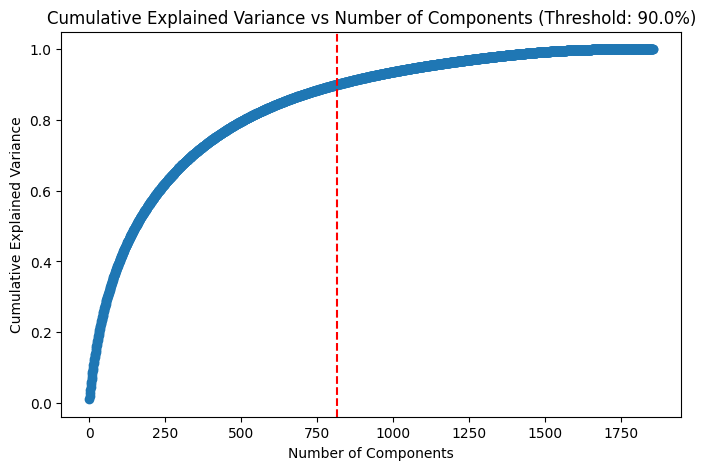

In [ ]:
# calculate PCA AND POV
pca = PCA()
X_pca = pca.fit_transform(tfidf_matrix.toarray())
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

threshold = 0.90
n_components = np.argmax(cumulative_variance >= threshold) + 1

print(f"تعداد مؤلفه‌های انتخابی برای پوشش {threshold * 100}% واریانس: {n_components}")

# plot the POV (Cumulative Explained Variance) diagram
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axvline(x=n_components, color='r', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title(f"Cumulative Explained Variance vs Number of Components (Threshold: {threshold*100}%)")
plt.show()

In [ ]:
# apply PCA to TF-IDF Features
pca = PCA(n_components=815)
tfidf_feature_pca = pca.fit_transform(tfidf_matrix.toarray())
tfidf_feature_pca.shape

(3665, 815)

In [ ]:
# construct user-item matrix
Y = data.pivot_table(index='StockCode', columns='CustomerID', values='Purchased', fill_value=0)
Y

CustomerID,12346,12347,12348,12349,12350,12352,12353,12354,12355,12356,...,18273,18274,18276,18277,18278,18280,18281,18282,18283,18287
StockCode,,,,,,,,,,,,,,,,,,,,,
10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DOT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
scalerUser = StandardScaler()

# removing unnecessary and non-numeric features
customer_features_array = customer_features.drop(columns=['CustomerID', 'Country', 'FirstPurchase', 'LastPurchase']).values

# scaling on customer features
user_features = scalerUser.fit_transform(customer_features_array)


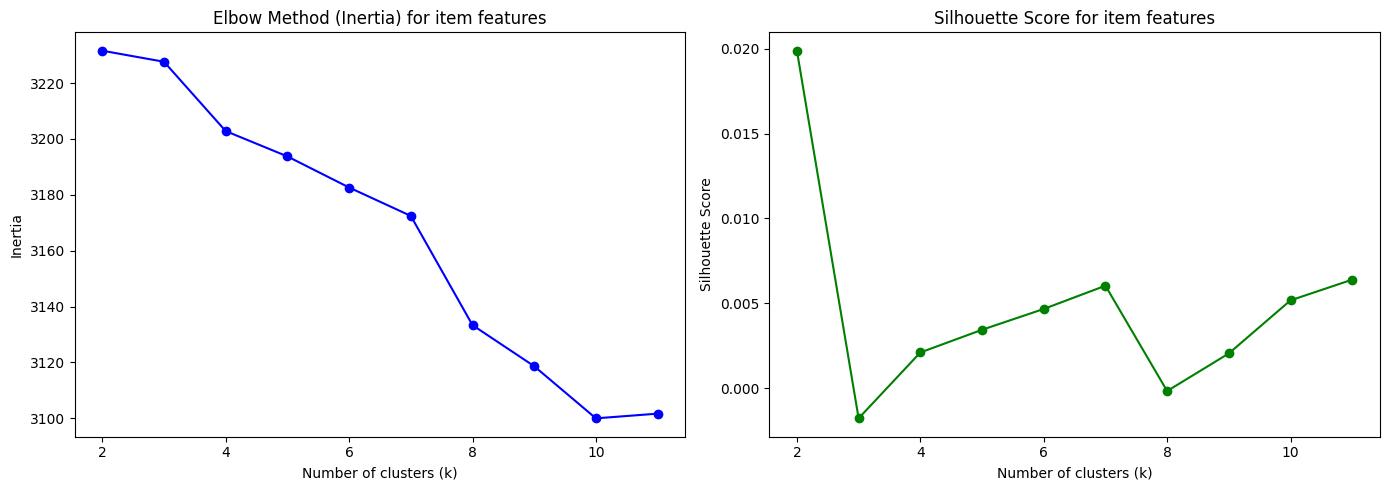

In [ ]:
# cluster number range
k_range = range(2, 12)
inertias2 = []
silhouette_scores2 = []

# runing K-means for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels2 = kmeans.fit_predict(tfidf_feature_pca)
    inertias2.append(kmeans.inertia_)
    silhouette_scores2.append(silhouette_score(tfidf_feature_pca, labels2))

# drawing Elbow and Silhouette Diagrams
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax[0].plot(k_range, inertias2, 'bo-')
ax[0].set_title("Elbow Method (Inertia) for item features")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")

# Silhouette Score Plot
ax[1].plot(k_range, silhouette_scores2, 'go-')
ax[1].set_title("Silhouette Score for item features")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


In [ ]:
# apply K-means for k=2 and assigning a cluster number to each product
kmeans = KMeans(n_clusters=2, random_state=42)
unique_products['Cluster'] = kmeans.fit_predict(tfidf_feature_pca)

In [ ]:
# calculating the number of samples in each cluster
unique, counts = np.unique(unique_products['Cluster'], return_counts=True)
cluster_counts = pd.DataFrame({'Cluster': unique, 'Count': counts})
print(cluster_counts)

   Cluster  Count
0        0    228
1        1   3437


In [ ]:
# applying one-hot encoding and joining to the features of TF-IDF
encoder = OneHotEncoder(sparse_output=False)
item_cluster_onehot = encoder.fit_transform(unique_products[['Cluster']])
tfidf_feature_pca = np.hstack([tfidf_feature_pca, item_cluster_onehot])
print("Item Features Shape:", tfidf_feature_pca.shape)

Item Features Shape: (3665, 817)


In [ ]:
# flatten rating matrix into 1D array with corresponding user and item indices
Y_array, user_indices, item_indices = Y.values.flatten(), np.tile(np.arange(Y.shape[1]), Y.shape[0]), np.repeat(np.arange(Y.shape[0]), Y.shape[1])

#  80/20 split: training set (80%) and temp set (20% for val/test)
# split temp set into validation (10%) and test (10%)
Y_train, Y_temp, item_indices_train, item_indices_temp, user_indices_train, user_indices_temp = train_test_split(Y_array, item_indices, user_indices, test_size=0.2, random_state=42)
Y_val, Y_test, item_indices_val, item_indices_test, user_indices_val, user_indices_test = train_test_split(Y_temp, item_indices_temp, user_indices_temp, test_size=0.5, random_state=42)

# create data generators for training, validation, and testing
train_gen = TripletDataGenerator(
    Y_train, user_features, tfidf_feature_pca, user_indices_train, item_indices_train,
    batch_size=256, shuffle=True)

val_gen = TripletDataGenerator(
    Y_val, user_features, tfidf_feature_pca, user_indices_val, item_indices_val,
    batch_size=256, shuffle=True)

test_gen = TripletDataGenerator(
    Y_test, user_features, tfidf_feature_pca, user_indices_test, item_indices_test,
    batch_size=256, shuffle=True)

In [ ]:
# get dimensionality of user and item feature vectors
user_dim = user_features.shape[1]
item_dim = tfidf_feature_pca.shape[1]

# build, compile and summary of triplet model.
model = build_triplet_model(user_dim, item_dim, embedding_dim=32)
model.compile(optimizer='adam', loss=info_nce_loss(temperature=0.07))
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 45)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_item_input      │ (None, 817)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neg_item_input      │ (None, 817)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32)        │     48,800 │ user_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 32)        │    246,432 │ pos_item_input[0… │
│ (Sequential)        │                   │            │ neg_item_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 32)        │          0 │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 32)        │          0 │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 32)        │          0 │ sequential_3[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ lambda_3[0][0],   │
│ (Concatenate)       │                   │            │ lambda_4[0][0],   │
│                     │                   │            │ lambda_5[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 295,232 (1.13 MB)

 Trainable params: 295,232 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model training
model.fit(train_gen, validation_data=val_gen, epochs=10)

Epoch 1/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - loss: 0.4452 - val_loss: 0.4121
Epoch 2/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - loss: 0.4020 - val_loss: 0.3927
Epoch 3/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.3873 - val_loss: 0.3859
Epoch 4/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.3775 - val_loss: 0.3795
Epoch 5/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.3696 - val_loss: 0.3766
Epoch 6/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.3625 - val_loss: 0.3795
Epoch 7/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.3581 - val_loss: 0.3804
Epoch 8/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.3528 - val_loss: 0.3705
Epoch 9/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - loss: 0.3514 - val_loss: 0.3733
Epoch 10/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 0.3459 - val_loss: 0.3724


In [58]:
# Evaluate model
eval_results = model.evaluate(test_gen)
print(f"Test Results - Loss: {eval_results}")

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3810
Test Results - Loss: 0.3809991478919983


In [ ]:
# extract user branch from the trained triplet model for inference

# get the user input layer (first input of the triplet model)
user_input = model.input[0]

# extract the user embedding output layer (sequential_2 contains the user embedding network)
user_embedding_output = model.get_layer("sequential_2").output

# create a standalone model that maps user features → 32-dim embedding
# this allows generating user embeddings without needing item inputs
user_NN = tf.keras.Model(inputs=user_input, outputs=user_embedding_output)

In [ ]:
# Extract item branch from the trained triplet model for inference

# Get the item input layer (second input of the triplet model)
item_input = model.input[1]  # model has 2 inputs: [user_input, item_input]

# Extract the item embedding output layer (sequential_3 contains the item embedding network)
item_embedding_output = model.get_layer("sequential_3").output

# Create a standalone model that maps item features → 32-dim embedding
# This allows generating item embeddings without needing user inputs
item_NN = tf.keras.Model(inputs=item_input, outputs=item_embedding_output)

In [ ]:
# Save the standalone user and item embedding models to disk
user_NN.save('./save_models/user_model_32d_7t_infonce_kmeans_debug32.keras')
item_NN.save('./save_models/item_model_32d_7t_infonce_kmeans_debug32.keras')

In [ ]:

# Step 1: Produce embeddings
user_embeddings = user_NN.predict(user_features)
item_embeddings = item_NN.predict(tfidf_feature_pca)

# Step 2: Normalize (if cosine similarity is used)
user_embeddings = tf.linalg.l2_normalize(user_embeddings, axis=1).numpy()
item_embeddings = tf.linalg.l2_normalize(item_embeddings, axis=1).numpy()

# Step 3: Compute predicted score for each (user, item) pair in test set
predicted_scores = np.sum(user_embeddings[user_indices_test] * item_embeddings[item_indices_test], axis=1)

# Step 4: Build results DataFrame
results_df = pd.DataFrame({
    "CustomerID": customer_features.iloc[user_indices_test]["CustomerID"].values,
    "StockCode": unique_products.iloc[item_indices_test]["StockCode"].values,
    "Predicted_Score": predicted_scores,
    "Actual": Y_test
})

# Step 5: Binary prediction (optional threshold)
results_df["Prediction_Binary"] = (results_df["Predicted_Score"] >= 0.0).astype(int)
results_df["Correct"] = (results_df["Prediction_Binary"] == results_df["Actual"]).astype(int)

# Print examples
print("✅ Correct Predictions:")
print(results_df[results_df["Correct"] == 1].head(10))

print("\n❌ Incorrect Predictions:")
print(results_df[results_df["Correct"] == 0].head(10))

accuracy = results_df["Correct"].mean()
print(f"\n🎯 Accuracy: {accuracy:.2%}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
✅ Correct Predictions:
    CustomerID StockCode  Predicted_Score  Actual  Prediction_Binary  Correct
0        15279     23419        -0.069389     0.0                  0        1
1        14895     23074        -0.013560     0.0                  0        1
2        17001     84050        -0.031441     0.0                  0        1
3        16701    84086B        -0.303458     0.0                  0        1
4        16284     90043        -0.154306     0.0                  0        1
9        16496    46776C        -0.349219     0.0                  0        1
11       17528     22157        -0.136477     0.0                  0        1
14       14174     85127        -0.076312     0.0                  0        1
15       13736    46000R        -0.082829     0.0                  0        1
19       12888    16162L        -0.037991     0.0                  0        1

❌ Incorrect Predictions:
    Custo

In [65]:
predicted_scores.shape

(1589877,)

In [66]:
K_values = [1, 3, 5, 10, 20]

# Compute metrics for different K
results = {
    "K": K_values,
    "Precision@K": [precision_at_k(results_df, k) for k in K_values],
    "Recall@K": [recall_at_k(results_df, k) for k in K_values],
    "F1-score@K": [f1_score_at_k(results_df, k) for k in K_values]
}

# Convert results to a dataframe
metrics_df = pd.DataFrame(results)

metrics_df

,K,Precision@K,Recall@K,F1-score@K
0,1,0.179806,0.035722,0.059603
1,3,0.151990,0.086587,0.110324
2,5,0.135869,0.124214,0.129780
3,10,0.114361,0.198022,0.144989
4,20,0.092554,0.304807,0.141993


In [ ]:
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [ ]:
print(f"Pandas version: {pd.__version__}")

Pandas version: 3.0.2


In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [ ]:
# import nltk

# # دانلود منابع مورد نیاز
# nltk.download('punkt')        # برای tokenization
# nltk.download('stopwords')     # برای stop words
# nltk.download('wordnet')       # برای lemmatization
# nltk.download('omw-1.4')       # منابع اضافی WordNet

# print("تمام منابع NLTK با موفقیت دانلود شدند!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\avatpc\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\avatpc\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\avatpc\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\avatpc\AppData\Roaming\nltk_data...


تمام منابع NLTK با موفقیت دانلود شدند!
